In [207]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,auc,classification_report,RocCurveDisplay

In [208]:
#read and inspect data
df= pd.read_csv("data.csv",index_col=0)
print(df.head())

   location  country  gender   age  vis_wuhan  from_wuhan  symptom1  symptom2  \
0       104        8       1  66.0          1           0        14        31   
1       101        8       0  56.0          0           1        14        31   
2       137        8       1  46.0          0           1        14        31   
3       116        8       0  60.0          1           0        14        31   
4       116        8       1  58.0          0           0        14        31   

   symptom3  symptom4  symptom5  symptom6  diff_sym_hos  result  
0        19        12         3         1             8       1  
1        19        12         3         1             0       0  
2        19        12         3         1            13       0  
3        19        12         3         1             0       0  
4        19        12         3         1             0       0  


In [209]:
data_length=len(df)
print(data_length)

863


In [210]:
X=df.drop("result",axis=1)
print(X.head())

   location  country  gender   age  vis_wuhan  from_wuhan  symptom1  symptom2  \
0       104        8       1  66.0          1           0        14        31   
1       101        8       0  56.0          0           1        14        31   
2       137        8       1  46.0          0           1        14        31   
3       116        8       0  60.0          1           0        14        31   
4       116        8       1  58.0          0           0        14        31   

   symptom3  symptom4  symptom5  symptom6  diff_sym_hos  
0        19        12         3         1             8  
1        19        12         3         1             0  
2        19        12         3         1            13  
3        19        12         3         1             0  
4        19        12         3         1             0  


In [211]:
y=df['result']
print(y.head())

0    1
1    0
2    0
3    0
4    0
Name: result, dtype: int64


In [212]:
#split data into 0.2 test data,0.2 validation data,0.6 train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) 

In [213]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  #fit on training data
X_test= scaler.transform(X_test)  
X_val = scaler.transform(X_val)  

In [214]:
y_train.value_counts()
#class 0 is over-represented so we over-sample the minority class (class 1)

result
0    453
1     64
Name: count, dtype: int64

In [215]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [216]:
print(y_train.value_counts())
#data is now balanced

result
0    453
1    453
Name: count, dtype: int64


Support vector machines
-

In [217]:
#fit the data
from sklearn.svm import SVC
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train,y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [218]:
#predict the data
y_val_predict_svm=svm.predict(X_val)
print(y_val_predict_svm)

[0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 0 0
 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1]


In [219]:
print ("SVM Metrics")
print(classification_report(y_val,y_val_predict_svm))
print('\n')
print(confusion_matrix(y_val,y_val_predict_svm))

SVM Metrics
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       149
           1       0.51      0.88      0.65        24

    accuracy                           0.87       173
   macro avg       0.74      0.87      0.78       173
weighted avg       0.91      0.87      0.88       173



[[129  20]
 [  3  21]]


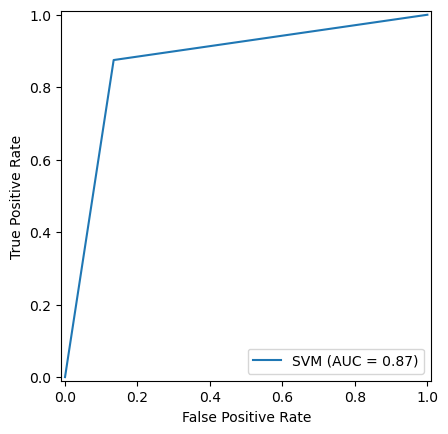

In [220]:
#extract probabilities of entry classification
y_proba_svm = svm.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_val, y_val_predict_svm)
# Calculate auc
roc_auc_svm = auc(fpr_svm, tpr_svm)
#display
display_svm = RocCurveDisplay(fpr=fpr_svm, tpr=tpr_svm, roc_auc=roc_auc_svm,estimator_name='SVM')

display_svm.plot()
plt.show()

Hyperparameter Tuning of SVMs
-

In [221]:
#using Grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'tol': [1e-4, 1e-3, 1e-2]  # Tolerance for stopping criteria
}

# Perform grid search
grid_search_svm = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring = 'recall') #to catch all positives
grid_search_svm.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search_svm.best_params_)
print("Best Cross-Validation Score:", grid_search_svm.best_score_)

# Use the best model for predictions
best_svm = grid_search_svm.best_estimator_
y_val_predict_best_svm = best_svm.predict(X_val)

Best Parameters: {'C': 100, 'tol': 0.01}
Best Cross-Validation Score: 0.9646886446886448


In [222]:
#display some metrics
print('SVM Metrics after tuning hyper parameters')
print(classification_report(y_val,y_val_predict_best_svm))
print('\nConfusion matrix')
print(confusion_matrix(y_val,y_val_predict_best_svm))

SVM Metrics after tuning hyper parameters
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       149
           1       0.51      0.88      0.65        24

    accuracy                           0.87       173
   macro avg       0.74      0.87      0.78       173
weighted avg       0.91      0.87      0.88       173


Confusion matrix
[[129  20]
 [  3  21]]


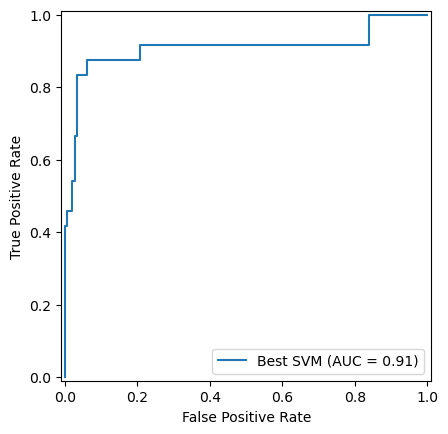

In [223]:
#extract probabilities of entry classification
y_proba_best_svm = best_svm.predict_proba(X_val)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_best_svm, tpr_best_svm, thresholds_best_svm = roc_curve(y_val, y_proba_best_svm)
# Calculate auc
roc_auc_best_svm = auc(fpr_best_svm, tpr_best_svm)
#display
display_best_svm = RocCurveDisplay(fpr=fpr_best_svm, tpr=tpr_best_svm, roc_auc=roc_auc_best_svm,estimator_name='Best SVM')

display_best_svm.plot()
plt.show()

In [224]:
y_test_predict_svm=best_svm.predict(X_test)
print(y_test_predict_svm)

[0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0]


In [225]:
#display some metrics
print('best SVM Metrics using test data')
print(classification_report(y_test,y_test_predict_svm))
print('\nConfusion matrix')
print(confusion_matrix(y_test,y_test_predict_svm))

best SVM Metrics using test data
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       153
           1       0.53      0.90      0.67        20

    accuracy                           0.90       173
   macro avg       0.76      0.90      0.80       173
weighted avg       0.93      0.90      0.91       173


Confusion matrix
[[137  16]
 [  2  18]]


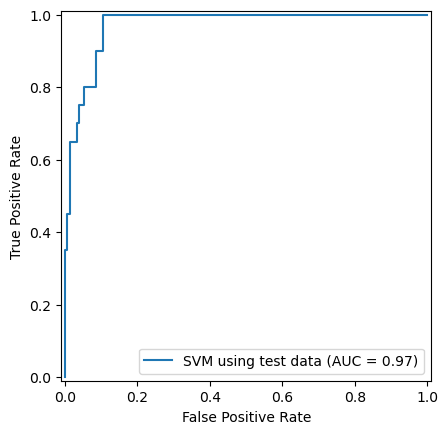

In [226]:
#extract probabilities of entry classification
y_proba_svm2 = best_svm.predict_proba(X_test)[:, 1]
# Calculate FPR, TPR, thresholds
fpr_svm2, tpr_svm2, thresholds_svm2 = roc_curve(y_test, y_proba_svm2)
# Calculate auc
roc_auc_svm2 = auc(fpr_svm2, tpr_svm2)
#display
display_svm2 = RocCurveDisplay(fpr=fpr_svm2, tpr=tpr_svm2, roc_auc=roc_auc_svm2,estimator_name='SVM using test data')

display_svm2.plot()
plt.show()